<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/group_exercises/exercise_1/Group_Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 2 – Data Preprocessing on a Real Dataset
# Group Exercise 1
Group consisting of Ritu, Vikrant Singh and Kay Müller

Dataset **"House Prices - Advanced Regression Techniques"**

The dataset contains properties with various environmental variables.

Source:
https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

##1. Handling Missing Values

Identify missing values

Apply appropriate imputation methods (mean, median, mode, or justified alternative)

In [17]:
# Load Kaggle dataset
df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/train_house.csv') # RAW Data from GitHub
#house_data.head()
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Shape: (1460, 81)

Missing values:
PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


In [18]:
from pandas.core.arrays import categorical
numerical_columns = df.select_dtypes(include='number').columns
#print(numerical_columns)
categorical_columns = df.select_dtypes(exclude='number').columns
#print(categorical_columns)

# numerical imputation
imput_median = SimpleImputer(strategy="median")
imput_mean = SimpleImputer(strategy="mean")

for feature in numerical_columns:

  if df[feature].isnull().sum().mean() == 0:  # if none are missing
    continue                                  # continue in the loop

  print(f"Numerical Feature {feature} missing: {df[feature].isnull().sum()}")
  if df[feature].skew() > 1 or df[feature].skew() < -1:
    # imput_median
    df[[feature]] = imput_median.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_median.strategy}")
  else:
    # imput_mean
    df[[feature]] = imput_mean.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_mean.strategy}")


# categorical imputation
imputer_mode = SimpleImputer(strategy="most_frequent")

for feature in categorical_columns:
  if df[feature].isnull().sum() == 0:
    continue

  print(f"Categorical Feature {feature} missing: {df[feature].isnull().sum()}")
  df[[feature]] = imputer_mode.fit_transform(df[[feature]])
  print(f"Categorical Feature {feature} imputed {imputer_mode.strategy}")

# Adjusted features
print("\nAdjusted features:")
print(df.isnull().sum().sort_values(ascending=False))


Numerical Feature LotFrontage missing: 259
Numerical Feature LotFrontage imputed median
Numerical Feature MasVnrArea missing: 8
Numerical Feature MasVnrArea imputed median
Numerical Feature GarageYrBlt missing: 81
Numerical Feature GarageYrBlt imputed mean
Categorical Feature Alley missing: 1369
Categorical Feature Alley imputed most_frequent
Categorical Feature MasVnrType missing: 872
Categorical Feature MasVnrType imputed most_frequent
Categorical Feature BsmtQual missing: 37
Categorical Feature BsmtQual imputed most_frequent
Categorical Feature BsmtCond missing: 37
Categorical Feature BsmtCond imputed most_frequent
Categorical Feature BsmtExposure missing: 38
Categorical Feature BsmtExposure imputed most_frequent
Categorical Feature BsmtFinType1 missing: 37
Categorical Feature BsmtFinType1 imputed most_frequent
Categorical Feature BsmtFinType2 missing: 38
Categorical Feature BsmtFinType2 imputed most_frequent
Categorical Feature Electrical missing: 1
Categorical Feature Electrical i

Explanation:

Mean is the better choice for symmetrical distributions, whereas median should be chosen for distributions with outliers and skewness. The categories are determined based on frequency.

##2. Scaling Numerical Features

Apply Z-score standardization

Apply Min–Max normalization

Briefly explain the difference

In [19]:
features = ['YearBuilt', 'SalePrice']
X = df[features].copy()

# Standardisation Z-Score
z_scaler = StandardScaler()
z_X = z_scaler.fit_transform(X)
z_X = pd.DataFrame(z_X, columns=[f + '_z' for f in features])

# Normalisation (Min Max)
mm_scaler = MinMaxScaler()
mm_X = mm_scaler.fit_transform(X)
mm_X = pd.DataFrame(mm_X, columns=[f + '_mm' for f in features])

# compared
comparsion = pd.concat([X, z_X, mm_X], axis=1)
print(comparsion.head())

   YearBuilt  SalePrice  YearBuilt_z  SalePrice_z  YearBuilt_mm  SalePrice_mm
0       2003     208500     1.050994     0.347273      0.949275      0.241078
1       1976     181500     0.156734     0.007288      0.753623      0.203583
2       2001     223500     0.984752     0.536154      0.934783      0.261908
3       1915     140000    -1.863632    -0.515281      0.311594      0.145952
4       2000     250000     0.951632     0.869843      0.927536      0.298709


Explanation

Z-score is preferable when data is approximately symmetrical/normally distributed. Each variable is given equal weighting. The Z-score is better suited to dealing with outliers. Min-max scaling, on the other hand, is useful when dealing with limited ranges, e.g. 0–1, i.e. features are required within strict limits.

##3. Handling Noise

Choose one numerical feature

Inject artificial noise

Apply a smoothing technique (e.g. rolling mean)

Show before vs after results

In [20]:
# numerical feature: Sales price
signal = df['SalePrice'].copy()

# Add artificial noise (small random variations) to this feature. "Reproducible"
np.random.seed(42)
noise = np.random.normal(loc=0, scale=1, size=len(signal))              # loc: mean, std (spread),

# Apply a simple noise-handling technique, Smoothing by aggregation
signal_noisy = signal + noise
signal_smoothed = signal_noisy.rolling(window=4, min_periods=1).mean()  # Slight smoothing and without NaN (1)

comparison_df = pd.DataFrame({
  'Orig. Signal': signal,
  'Noisy': signal_noisy,
  'Smoothed': signal_smoothed

})

print(comparison_df.head(10))

   Orig. Signal          Noisy       Smoothed
0        208500  208500.496714  208500.496714
1        181500  181499.861736  195000.179225
2        223500  223500.647689  204500.335379
3        140000  140001.523030  188375.632292
4        250000  249999.765847  198750.449575
5        143000  142999.765863  189125.425607
6        307000  307001.579213  210000.658488
7        200000  200000.767435  225000.469589
8        129900  129899.530526  194975.410759
9        118000  118000.542560  188725.604933


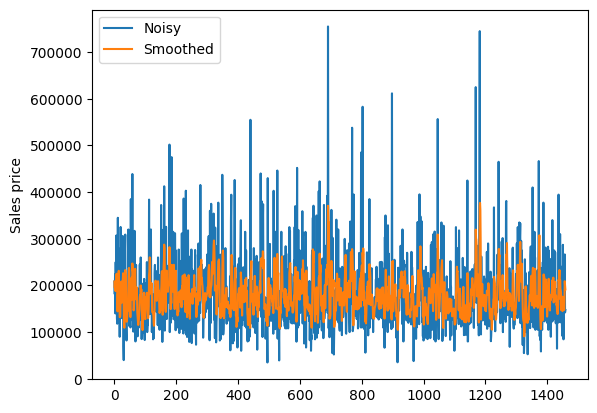

In [21]:
plt.plot(signal_noisy, label='Noisy')
plt.plot(signal_smoothed, label='Smoothed')
plt.ylabel('Sales price')
plt.legend()
plt.show()

Conclusion:

The input signal is already very "unstable". The aim is to attenuate outliers in the effect in order to better interpret the "signal". It is important not to completely "smooth" the noise, as otherwise information may be lost or the interpretation may be distorted.

##4. Handling Outliers

Detect outliers using Z-score

Handle them via removal or transformation

Justify your approach

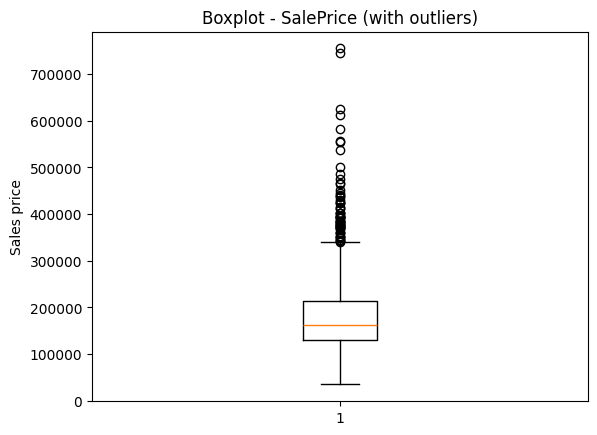

In [22]:
plt.boxplot(df['SalePrice'])
plt.title('Boxplot - SalePrice (with outliers)')
plt.ylabel('Sales price')
plt.show()

In [23]:
df['SalePrice_z_score'] = zscore(df['SalePrice'])

outliers = df[np.abs(df['SalePrice_z_score']) > 3]

print("Outliers:", len(outliers))

Outliers: 22


### Treat outliers:

Deleted outliers: 22


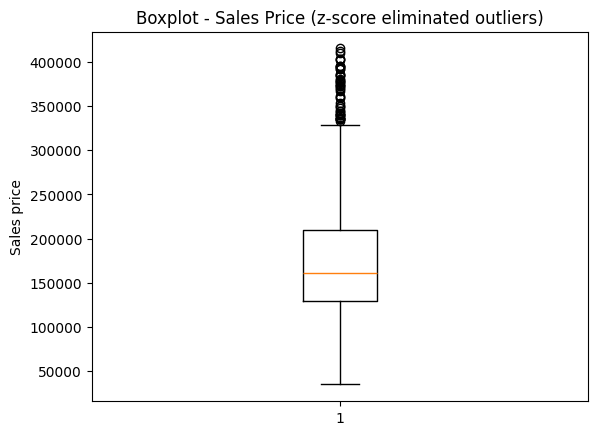

In [24]:
# Delete outliers using z-score

threshold = 3 # Outliers (> 99,7% der normal distribution)

df_no_outliers = df[np.abs(df['SalePrice_z_score']) <= threshold]

print("Deleted outliers:", len(df) - len(df_no_outliers))

plt.boxplot(df_no_outliers['SalePrice'])
plt.title('Boxplot - Sales Price (z-score eliminated outliers)')
plt.ylabel('Sales price')
plt.show()

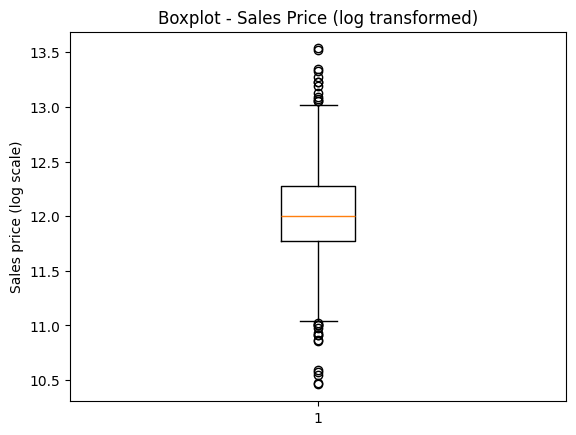

In [25]:
# Reduce outliers using log1p transformation

df['SalePrice_log_transform'] = np.log1p(df['SalePrice'])

plt.boxplot(df['SalePrice_log_transform'])
plt.title('Boxplot - Sales Price (log transformed)')
plt.ylabel('Sales price (log scale)')
plt.show()

Conclusion:

Eliminating outliers using Z-scores is not necessarily useful here, as the authenticity of the core data is not preserved and extreme outliers are eliminated. For example, luxury properties may be just as relevant to the price structure of other properties. Log transformation is the better choice here.

#5. Feature Selection

Apply at least one of the following:

Filter method (e.g. correlation, mutual information)

Wrapper method (e.g. RFE)

Embedded method (e.g. Lasso)

###Version 1: Lasso (simple)

In [26]:
# Ensuring that there are no missing values
#print(df.isnull().sum().sort_values(ascending=False))

X = df[['YearBuilt', 'LotArea']]          # influencing factors (if necessary further scaling required)
y = df['SalePrice']                       # target value

lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X, y)

pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_})  #  If coefficient is higher, feature increases price



,Feature,Coefficient
0,YearBuilt,1365.776044
1,LotArea,2.041172


###Version 2: Lasso optimised with more influencing factors, scaler and training

In [27]:
# Ensuring that there are no missing values
#print(df.isnull().sum().sort_values(ascending=False))

# Feature grouping (splitting)
numerical_cols = ['YearBuilt', 'LotArea', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea']
categorical_cols = ['Neighborhood']

X = df[numerical_cols + categorical_cols]                                         # influencing factors (if necessary further scaling required)
y = df['SalePrice']                                                               # target value

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   # 80% Trainingset and 20% Testset

# One-Hot-Encoder (Categorical cols), StandardScaler
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),                                # Scaling mean close to 0 and standard deviation close to 1
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)         # One-Hot-Encoder on 'Neighborhood'
    ])


# Process pipeline (Preparation --> Lasso)
model = Pipeline(steps=[
  ('preprocess', preprocess),
  ('lasso', Lasso(alpha=0.01, max_iter=50000, tol=0.01, random_state=42))         # Alpha: small (a large alpha would pull the coefficients more strongly towards 0)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: The model is on average approx {rmse:.0f} beside.")

# Get training data (Lasso)
lasso = model.named_steps['lasso']

# Get preprocessor
ctg = model.named_steps['preprocess']

# Pick up features and merge
num_cols = numerical_cols
ohe_cat = ctg.named_transformers_['cat']
cat_cols = ohe_cat.get_feature_names_out(categorical_cols)        # DICT: Returns the new column names from Transformer

features = np.concatenate([num_cols, cat_cols])                   # Merge list

# DF coefficient
coefs = lasso.coef_                                               # Coefficients from Lasso model
coef_df = pd.DataFrame({                                          # DataFrame with two columns
    'Feature': features,
    'Coefficient': coefs
})

# Sorting (by importance)
coef_df['AbsCoeff'] = coef_df['Coefficient'].abs()                # Amount of the coefficients
coef_df = coef_df.sort_values(by='AbsCoeff', ascending=False)
print("\nCoefficient:")
print(coef_df.head(15))


RMSE: The model is on average approx 37398 beside.

Coefficient:
                 Feature   Coefficient      AbsCoeff
28  Neighborhood_StoneBr  54907.618863  54907.618863
22  Neighborhood_NridgHt  49937.923937  49937.923937
21  Neighborhood_NoRidge  46725.337831  46725.337831
30  Neighborhood_Veenker  41506.555890  41506.555890
7   Neighborhood_Blueste -37844.444221  37844.444221
8    Neighborhood_BrDale -37475.084536  37475.084536
12  Neighborhood_Crawfor  28005.777728  28005.777728
3              GrLivArea  24604.668117  24604.668117
2            OverallQual  24179.516120  24179.516120
19  Neighborhood_NPkVill -17898.103064  17898.103064
10  Neighborhood_ClearCr  16517.639900  16517.639900
6   Neighborhood_Blmngtn -14932.883554  14932.883554
16  Neighborhood_MeadowV -13941.081234  13941.081234
14  Neighborhood_Gilbert -12386.151299  12386.151299
0              YearBuilt  12225.837571  12225.837571


Note: Coefficient indicates the direction and strength of influence, while AbsCoeff focuses only on the strength or importance of influence.

**Visual weighting of features**

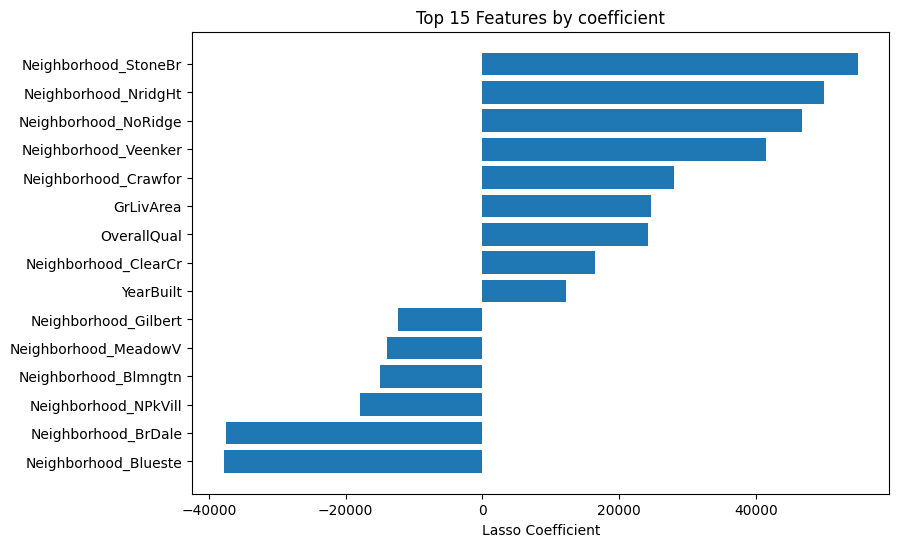

In [28]:
top_n = 15
plot_df = coef_df.head(top_n).sort_values('Coefficient')
plt.figure(figsize=(9,6))
plt.barh(plot_df['Feature'], plot_df['Coefficient'])
plt.xlabel('Lasso Coefficient')
plt.title(f'Top {top_n} Features by coefficient')
plt.show()

Explanation:

Models such as Lasso are sensitive to the magnitude of features (features with high values in the context of features with low values). The aim of scaling is to make the features more comparable. The coefficient indicates how a feature affects the price.

*Lasso evaluates influence in the model.*

###Version 3: Recursive Feature Elimination - Ridge

In [29]:
X_train_process = preprocess.fit_transform(X_train)     # n_train_samples and feature according to OHE
X_test_process = preprocess.transform(X_test)           # same column order

# Ridge, linear regression (L2 regularisation)
base_estimator = Ridge(alpha=1.0, random_state=42)      # alpha regularisation strength (against overfitting)

# Feature goal at the end
feature_choice = 15

# Recursive Feature Elimination (Ridge) - Feature goal; one feature is removed with each step (precise but slow)
rfe = RFE(estimator=base_estimator, n_features_to_select=feature_choice, step=1)

# Ridge model adjustment, feature importance determination, iterative removal of weakest features
rfe.fit(X_train_process, y_train)

# Boolean decision in an array, which feature was retained and which was removed
mask = rfe.support_
sel_features = features[mask]                           # remaining features

# Training only on the remaining features - Ridge model
X_train_sel = X_train_process[:, mask]
X_test_sel = X_test_process[:, mask]

ridge_sel = Ridge(alpha=1.0, random_state=42)
ridge_sel.fit(X_train_sel, y_train)

y_pred = ridge_sel.predict(X_test_sel)                   # Forecast (selected features)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"\nTop {feature_choice} Features: \n{sel_features}")
print(f"\nRMSE with RFE and Ridge: {rmse:.0f}")

# Parameter
target_feature = 'SalePrice'

# Numerical feature + OneHotEnc. Feature + Target parameter
df_ohe = pd.get_dummies(df[categorical_cols], drop_first=False)
df_corr = pd.concat([df[numerical_cols], df_ohe, df[target_feature]], axis=1)

# Calculate correlation
correlation = df_corr.corr()[target_feature].drop(target_feature)

corr_df = pd.DataFrame({
    'Feature': correlation.index,
    'Corr': correlation.values,
})

# Add absolute amount (importance sorting/determination)
corr_df['AbsCorr'] = corr_df['Corr'].abs()
corr_df = corr_df.sort_values(by='AbsCorr', ascending=False)

print("\nCorrelation:")
print(corr_df.head(15))



Top 15 Features: 
['YearBuilt' 'OverallQual' 'GrLivArea' 'Neighborhood_Blmngtn'
 'Neighborhood_Blueste' 'Neighborhood_BrDale' 'Neighborhood_BrkSide'
 'Neighborhood_ClearCr' 'Neighborhood_Crawfor' 'Neighborhood_Gilbert'
 'Neighborhood_NPkVill' 'Neighborhood_NoRidge' 'Neighborhood_NridgHt'
 'Neighborhood_StoneBr' 'Neighborhood_Veenker']

RMSE with RFE and Ridge: 38954

Correlation:
                 Feature      Corr   AbsCorr
2            OverallQual  0.790982  0.790982
3              GrLivArea  0.708624  0.708624
4             GarageCars  0.640409  0.640409
5             GarageArea  0.623431  0.623431
0              YearBuilt  0.522897  0.522897
22  Neighborhood_NridgHt  0.402149  0.402149
21  Neighborhood_NoRidge  0.330424  0.330424
1                LotArea  0.263843  0.263843
28  Neighborhood_StoneBr  0.215363  0.215363
23  Neighborhood_OldTown -0.192189  0.192189
18    Neighborhood_NAmes -0.188513  0.188513
13  Neighborhood_Edwards -0.179949  0.179949
15   Neighborhood_IDOTRR -0.164

**Visual weighting of features**

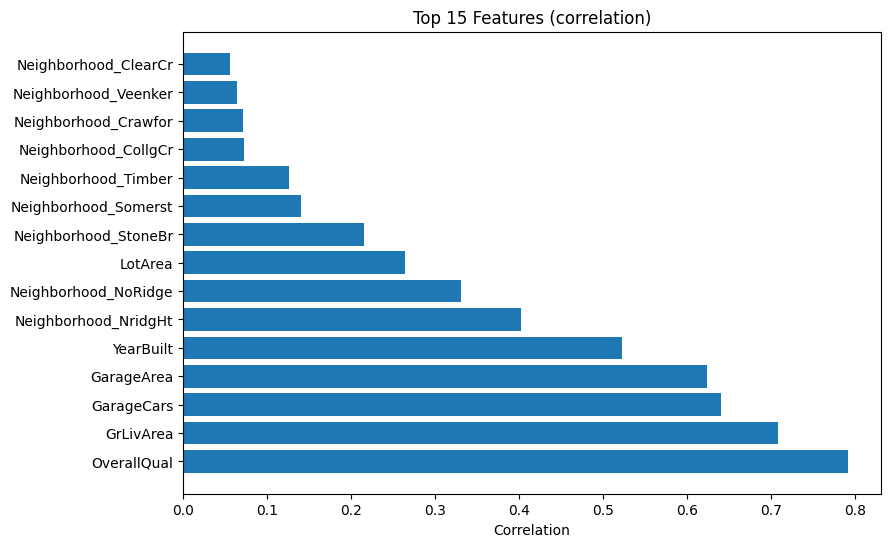

In [30]:
top_n = 15
plot_df = corr_df.sort_values('Corr', ascending=False).head(top_n)
plt.figure(figsize=(9,6))
plt.barh(plot_df['Feature'], plot_df['Corr'])
plt.xlabel('Correlation')
plt.title(f'Top {top_n} Features (correlation)')
plt.show()

Explanation:

The RMSE is similar to that of Lasso. In some cases, Lasso RMSE provides slightly better predictions. The location is weighted more heavily in Lasso than in the correlation shown here.

*The correlation measures linear relationships.*